# Diginetica: Recommender models

## 1. Introduction 

This notebook builds the two recommender techniques on the processed Diginetica data from notebook 01. The models are implemented from scratch using only numpy, pandas and scikit-learn, so no dedicated recommender library is used. The order is: first matrix factorization (SVD, technique A), then an extension of it (SVD++), and finally item-based collaborative filtering (Item-KNN, technique D), which is evaluated both as a rating prediction and as a classification task.

The model is trained with stochastic gradient descent (SGD), which updates the parameters after each individual interaction, rather than batch gradient descent, which would process all interactions before making a single update. SGD is the standard optimization method for this type of matrix factorization model, as described by Koren et al. (2009). The underlying model itself, baseline predictors with latent factors, was presented in the lecture (Bhaumik, 2024b), while SGD is the training method introduced in that paper. SGD also fits the data well for two reasons: the dataset is large, so updating after every interaction converges faster than waiting for a full pass, and each interaction only involves one session and one item, so SGD updates exactly the few parameters that are relevant while leaving the rest untouched. This matches the very sparse structure of the interaction matrix.

### 1.1 Load the processed interactions

I load the cleaned interaction file that was saved at the end of the "Diginetica EDA" notebook. This file already contains the proxy rating, the purchase label, and the encoded session and item indices, so no cleaning has to be repeated here.

In [19]:
import numpy as np
import pandas as pd

# Load the cleaned interactions produced by notebook 01.
inter = pd.read_parquet("diginetica_interactions.parquet")

# Number of sessions and items, taken from the encoded indices (0..n-1).
n_sessions = int(inter['session_idx'].max()) + 1
n_items = int(inter['item_idx'].max()) + 1

print("Interactions:", len(inter))
print("Sessions:", n_sessions, "| Items:", n_items)
print(inter.head())

Interactions: 696481
Sessions: 129975 | Items: 41258
   session_id  item_id  rating  purchased  session_idx  item_idx
0           1     9654     1.0          0            0         0
1           1    12352     1.0          0            0         1
2           1    31331     1.0          0            0         2
3           1    32118     1.0          0            0         3
4           1    32627     1.0          0            0         4


### 1.2 Train, validation and test split

To measure how well the models predict unseen interactions, the data is split into a training set, a validation set and a test set. The training set is used to fit the models, the validation set is used to tune the settings, and the test set is only used for the final scores.

The split is made per session rather than fully at random. For each session, its interactions are shuffled and divided over the three sets, so that every session appears in all three. This is important because the models can only predict for sessions and items they have seen during training. A purely random split could place all interactions of a short session in one set, leaving that session with no training data. Splitting per session avoids this and matches the splitting approach used on the other dataset. Because most sessions are short, a fixed 80/10/10 split per session is not possible, so each session is given at least one validation interaction and one test interaction, with the remaining interactions assigned to training.

In [23]:
# Split each session's interactions over train, validation and test.
# Each session gives at least 1 interaction to validation and 1 to test,
# so no set is ever empty, even for short sessions. The rest goes to training.
train_list, val_list, test_list = [], [], []

for session, group in inter.groupby('session_idx'):
    # Only sessions with at least 3 interactions can fill all three sets.
    if len(group) >= 3:
        # Shuffle the interactions of this session for a random division.
        shuffled = group.sample(frac=1, random_state=42)
        n = len(shuffled)

        # Aim for 10% in validation and 10% in test, but always at least 1 each.
        n_val = max(1, int(n * 0.1))
        n_test = max(1, int(n * 0.1))
        # The remaining interactions form the training part.
        n_train = n - n_val - n_test

        train_list.append(shuffled.iloc[:n_train])
        val_list.append(shuffled.iloc[n_train:n_train + n_val])
        test_list.append(shuffled.iloc[n_train + n_val:])

# Combine all sessions back into three dataframes.
train_df = pd.concat(train_list).reset_index(drop=True)
val_df = pd.concat(val_list).reset_index(drop=True)
test_df = pd.concat(test_list).reset_index(drop=True)

# Report the resulting sizes and the actual proportions.
total = len(train_df) + len(val_df) + len(test_df)
print("Train:", len(train_df), f"({len(train_df)/total:.1%})")
print("Validation:", len(val_df), f"({len(val_df)/total:.1%})")
print("Test:", len(test_df), f"({len(test_df)/total:.1%})")

# Global average rating on the training set (used as the baseline in the model).
mu = train_df['rating'].mean()
print("Global average rating (mu):", round(mu, 4))

Train: 435195 (62.5%)
Validation: 130643 (18.8%)
Test: 130643 (18.8%)
Global average rating (mu): 1.0276


### Interpretation

The per-session split results in about 62.5% of the interactions in training, 18.8% in validation and 18.8% in test. These proportions differ from a standard 80/10/10 split, which is a direct consequence of the many short sessions in the data: for a session with only three interactions, the only way to fill all three sets is to assign one interaction to each, which raises the share of the validation and test sets above 10%. The training set still holds the majority of the data, and the validation and test sets each contain about 130,000 interactions, which is more than enough to tune and evaluate the models reliably.

The global average rating on the training set is 1.0276, which is very close to 1. This confirms the strong imbalance found in the EDA: almost all interactions are views (rating 1) and only a small fraction are purchases (rating 3). This low average is the baseline that the SVD model starts from before adding the session and item effects.

## 2. Technique A: Matrix Factorization (SVD)

### 2.1 The model

The SVD model predicts a rating for a session–item pair as the sum of three parts: the global average rating, a bias for the session, a bias for the item, and the interaction between their latent factors (k). In formula form the prediction is:

`r_hat(u, i) = mu + b_u + b_i + p_u · q_i`

Here `mu` is the global average, `b_u` and `b_i` are the session and item biases (how much they differ from the average), and `p_u` and `q_i` are latent factor vectors that capture hidden patterns, as explained in the lecture on baseline predictors and matrix factorization. The model learns these values by minimizing the squared error between the predicted and the real ratings, with a regularization term that keeps the values small to avoid overfitting. Training is done with stochastic gradient descent, which updates the values one interaction at a time.

In [24]:
# Hyperparameters for the model. These are chosen as common starting values and can be tuned on the validation set.
n_factors = 20      # number of latent factors (k) per session and item
lr = 0.01           # learning rate (step size of each update)
reg = 0.05          # regularization strength (penalty on large values)
n_epochs = 15       # number of passes over the training data

# Initialize the parameters.
init_rng = np.random.default_rng(0)
# Small random latent factors (k) for sessions (P) and items (Q).
P = init_rng.normal(0, 0.1, (n_sessions, n_factors))
Q = init_rng.normal(0, 0.1, (n_items, n_factors))
# Biases start at zero.
b_u = np.zeros(n_sessions)
b_i = np.zeros(n_items)

print("P shape (sessions x factors):", P.shape)
print("Q shape (items x factors):", Q.shape)

P shape (sessions x factors): (129975, 20)
Q shape (items x factors): (41258, 20)


### Interpretation

The session factor matrix P has shape (129,975 × 20) and the item factor matrix Q has shape (41,258 × 20), which matches the number of sessions and items in the training data and the chosen number of 20 latent factors. This confirms that the model parameters are set up correctly before training: each session and each item has its own latent factor vector, and both biases are initialized at zero.

### 2.2 Training function

The training is wrapped in a function so it can be reused with different settings. The function builds the model from scratch: it initializes the session and item biases at zero and the latent factors (k) as small random values, then improves them with stochastic gradient descent. For each interaction it computes the prediction error and nudges the biases and factors a small step in the direction that reduces that error, with a regularization term that keeps the values small to prevent overfitting. The function returns the learned parameters and the validation RMSE after the final epoch, which is used in the next section to compare different numbers of latent factors (k).

The model is trained with stochastic gradient descent (SGD), which updates the parameters after each individual interaction, rather than batch gradient descent, which would process all interactions before making a single update. SGD is the standard optimization method for this type of matrix factorization model, following the baseline-plus-factors formulation of Koren et al. (2009), which is also the basis of the SVD model presented in the lecture. It also fits the data well for two reasons: the dataset is large, so updating after every interaction converges faster than waiting for a full pass, and each interaction only involves one session and one item, so SGD updates exactly the few parameters that are relevant while leaving the rest untouched. This matches the very sparse structure of the interaction matrix.

In [25]:
# Overall average rating on the training set. This is the baseline that the model starts from before adding the session bias, item bias and latent factors (k).
mu = train_df['rating'].mean()

# Put the training columns into plain numpy arrays for speed.
u_arr = train_df['session_idx'].to_numpy()
i_arr = train_df['item_idx'].to_numpy()
r_arr = train_df['rating'].to_numpy(dtype=float)


def train_svd(n_factors, lr=0.01, reg=0.05, n_epochs=15, seed=0, verbose=False):
    """Train an SVD model from scratch with stochastic gradient descent.
    Returns the learned biases, latent factors (k), and the final validation RMSE."""

    # Initialize parameters. Biases start at zero; latent factors (k) start small and random.
    init_rng = np.random.default_rng(seed)
    P = init_rng.normal(0, 0.1, (n_sessions, n_factors))   # session factors
    Q = init_rng.normal(0, 0.1, (n_items, n_factors))      # item factors
    b_u = np.zeros(n_sessions)                             # session biases
    b_i = np.zeros(n_items)                                # item biases

    # Helper to predict ratings for arrays of sessions and items.
    # Predictions are clipped to the rating range (1 = view, 3 = purchase).
    def predict(u, i):
        pred = mu + b_u[u] + b_i[i] + np.sum(P[u] * Q[i], axis=1)
        return np.clip(pred, 1.0, 3.0)

    # Helper to compute RMSE on a dataframe.
    def rmse(df):
        p = predict(df['session_idx'].to_numpy(), df['item_idx'].to_numpy())
        return np.sqrt(np.mean((df['rating'].to_numpy() - p) ** 2))

    # Training loop: several passes (epochs) over all interactions.
    train_rng = np.random.default_rng(seed + 1)
    for epoch in range(n_epochs):
        order = train_rng.permutation(len(u_arr))   # shuffle order each epoch
        for idx in order:
            uu, ii = u_arr[idx], i_arr[idx]
            # Prediction error for this single interaction.
            pred = mu + b_u[uu] + b_i[ii] + P[uu] @ Q[ii]
            err = r_arr[idx] - pred
            # Update biases.
            b_u[uu] += lr * (err - reg * b_u[uu])
            b_i[ii] += lr * (err - reg * b_i[ii])
            # Update latent factors (k) (keep old P value to update Q correctly).
            Pu = P[uu].copy()
            P[uu] += lr * (err * Q[ii] - reg * P[uu])
            Q[ii] += lr * (err * Pu - reg * Q[ii])
        if verbose:
            print(f"  epoch {epoch + 1:2d} | train RMSE: {rmse(train_df):.4f} | val RMSE: {rmse(val_df):.4f}")

    # Return everything needed to make predictions later, plus the final val RMSE.
    return {'P': P, 'Q': Q, 'b_u': b_u, 'b_i': b_i,
            'predict': predict, 'val_rmse': rmse(val_df)}

### 2.3 Choosing the number of latent factors (k)

The number of latent factors (k) controls how detailed the model is. Too few factors cannot capture enough patterns (underfitting), while too many can start to model noise (overfitting). To choose a good value, the model is trained with several numbers of factors and each one is scored on the validation set, which was not used for training. The value with the lowest validation RMSE is selected and used for the final model.

To keep this search fast, a smaller number of epochs is used here than for the final model. The goal of the search is only to compare the factor sizes against each other, not to fully train each one, so a shorter training run is enough to see which factor size performs best. The selected factor size is then trained more thoroughly in the next section.

In [26]:
# Try several numbers of latent factors (k) and keep the validation RMSE for each.
# A shorter training run (fewer epochs) is used here, because the search only needs to compare the factor sizes, not fully train each model.
factor_values = [10, 20, 40, 60, 80, 100]
grid_results = []

for k in factor_values:
    model_k = train_svd(n_factors=k, n_epochs=10)
    grid_results.append({'n_factors': k, 'val_rmse': model_k['val_rmse']})
    print(f"n_factors={k:3d} | val RMSE: {model_k['val_rmse']:.4f}")

# Put the results in a table and pick the number of factors with the lowest val RMSE.
grid_df = pd.DataFrame(grid_results)
best_k = int(grid_df.loc[grid_df['val_rmse'].idxmin(), 'n_factors'])
print("\nBest number of factors:", best_k)

n_factors= 10 | val RMSE: 0.2437
n_factors= 20 | val RMSE: 0.2443
n_factors= 40 | val RMSE: 0.2458
n_factors= 60 | val RMSE: 0.2475
n_factors= 80 | val RMSE: 0.2492
n_factors=100 | val RMSE: 0.2504

Best number of factors: 10


### Interpretation

The validation RMSE is lowest at 10 latent factors (0.2437) and rises steadily as more factors are added, up to 0.2504 at 100 factors. A small number of factors therefore already captures the useful structure in the data, and adding more factors only makes the validation performance worse. This is a clear sign of overfitting: the larger models describe the training data in more detail but generalize less well to unseen interactions. The differences are small, which shows the model is stable across factor sizes, but the trend is consistent.

This pattern is expected given the extreme sparsity of the data (about 99.99% of session–item pairs are unobserved). With so few observed interactions per session and item, there is not enough signal to estimate many latent factors reliably, so a simpler model generalizes better. Based on this result, 10 latent factors is selected for the final model.

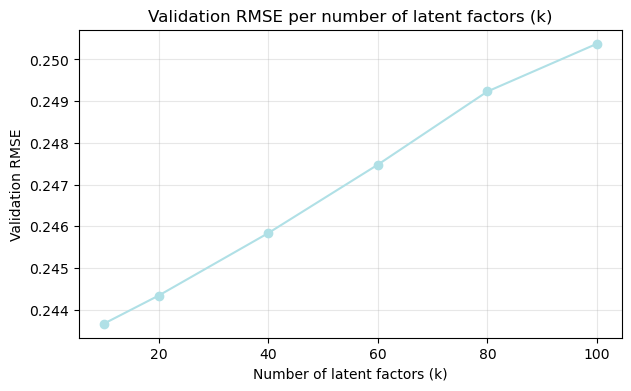

In [58]:
import matplotlib.pyplot as plt

# Plot validation RMSE against the number of latent factors (k) to show the trend.
plt.figure(figsize=(7, 4))
plt.plot(grid_df['n_factors'], grid_df['val_rmse'], marker='o', color='powderblue')
plt.xlabel('Number of latent factors (k)')
plt.ylabel('Validation RMSE')
plt.title('Validation RMSE per number of latent factors (k)')
plt.grid(alpha=0.3)
plt.show()

### Interpretation

The plot shows a clear upward trend: the validation RMSE is at its lowest with 10 latent factors and increases steadily as more factors are added. There is no dip further to the right, which means adding capacity to the model only makes its validation performance worse, confirming the overfitting seen in the table. The y-axis covers only a small range (about 0.244 to 0.251), so the differences are small in absolute terms and the model is not very sensitive to this setting. Still, the trend is consistent enough to justify choosing the simplest well-performing option, which is 10 latent factors.

### 2.4 Final model and evaluation on the test set

Using the best number of factors found above, the final model is trained and then evaluated on the test set, which was not used during training or tuning. Two predictive accuracy metrics from the lecture are reported: the root mean squared error (RMSE) and the mean absolute error (MAE). Both measure how close the predicted ratings are to the real ones, where lower is better.

In [28]:
# Train the final model with the best number of factors. More epochs are used here than in the search, so the selected model is trained thoroughly before evaluation.
print(f"Training final SVD model with {best_k} factors:")
svd_model = train_svd(n_factors=best_k, n_epochs=20, verbose=True)

# Predict on the test set using the trained model.
test_pred = svd_model['predict'](test_df['session_idx'].to_numpy(),
                                 test_df['item_idx'].to_numpy())
test_true = test_df['rating'].to_numpy()

# Predictive accuracy metrics.
svd_rmse = np.sqrt(np.mean((test_true - test_pred) ** 2))
svd_mae = np.mean(np.abs(test_true - test_pred))

print("\nSVD test RMSE:", round(svd_rmse, 4))
print("SVD test MAE:", round(svd_mae, 4))

Training final SVD model with 10 factors:
  epoch  1 | train RMSE: 0.2277 | val RMSE: 0.2497
  epoch  2 | train RMSE: 0.2219 | val RMSE: 0.2483
  epoch  3 | train RMSE: 0.2169 | val RMSE: 0.2473
  epoch  4 | train RMSE: 0.2127 | val RMSE: 0.2465
  epoch  5 | train RMSE: 0.2089 | val RMSE: 0.2457
  epoch  6 | train RMSE: 0.2055 | val RMSE: 0.2452
  epoch  7 | train RMSE: 0.2024 | val RMSE: 0.2447
  epoch  8 | train RMSE: 0.1995 | val RMSE: 0.2443
  epoch  9 | train RMSE: 0.1970 | val RMSE: 0.2439
  epoch 10 | train RMSE: 0.1946 | val RMSE: 0.2437
  epoch 11 | train RMSE: 0.1923 | val RMSE: 0.2434
  epoch 12 | train RMSE: 0.1903 | val RMSE: 0.2432
  epoch 13 | train RMSE: 0.1883 | val RMSE: 0.2431
  epoch 14 | train RMSE: 0.1865 | val RMSE: 0.2430
  epoch 15 | train RMSE: 0.1848 | val RMSE: 0.2429
  epoch 16 | train RMSE: 0.1832 | val RMSE: 0.2429
  epoch 17 | train RMSE: 0.1816 | val RMSE: 0.2428
  epoch 18 | train RMSE: 0.1802 | val RMSE: 0.2428
  epoch 19 | train RMSE: 0.1788 | val RM

### Interpretation

During training the train RMSE keeps falling (from 0.2277 to 0.1774 over 20 epochs), while the validation RMSE falls more slowly and then flattens out around 0.2428 to 0.2429 from about epoch 16. That gap, a train RMSE still going down while the validation RMSE has stalled, tells me the model has learned the useful patterns and that more training mainly fits the training data closer without helping generalization. Stopping around 20 epochs therefore seems reasonable.

On the test set, which was not used during training or tuning, the model reaches an RMSE of 0.246 and an MAE of 0.0641. Both are low on the 1-to-3 scale, so on average the predicted ratings are close to the real ones, and the test RMSE is very close to the final validation RMSE, which suggests the model generalizes well.

I do want to read this low error carefully, though. Because views (rating 1) far outnumber purchases (rating 3), most true ratings are 1, and a model that predicts values near 1 is right most of the time. The low RMSE and MAE mainly show that the frequent views are predicted well; they do not by themselves prove the model can separate purchases from views. The ranking and classification evaluations look at that.

### 2.5 Top-N ranking evaluation

RMSE and MAE measure how close the predicted ratings are to the true ratings, but a recommender system is mainly judged on whether it puts the right items at the top of its list. This is measured with rank accuracy metrics, as described in the lecture. For each session, the model scores all items, the items the session actually interacted with in the test set are held out as the relevant items, and three metrics are computed on the top-K recommendations: Precision@K, Recall@K and HitRate@K. The evaluation is run on a random sample of test sessions, which is a common approach for large datasets, and items the session already saw in training are excluded so the model is only credited for recommending new items.

I first evaluate at the standard K=10, which is the value used most often in the literature.

In [29]:
# For each session, collect the items it interacted with in train and in test.
# Train items are excluded from recommendations; test items are the "relevant" items.
train_items_per_session = train_df.groupby('session_idx')['item_idx'].apply(set)
test_items_per_session = test_df.groupby('session_idx')['item_idx'].apply(set)


def evaluate_topn(predict_scores, K=10, n_sample=2000, seed=42):
    """Evaluate top-K ranking quality on a random sample of test sessions.
    `predict_scores` is a function that returns a score for every item given a session.
    Returns Precision@K, Recall@K and HitRate@K averaged over the sampled sessions."""

    # Take a random sample of sessions that appear in the test set.
    eval_rng = np.random.default_rng(seed)
    test_sessions = test_items_per_session.index.to_numpy()
    sample = eval_rng.choice(test_sessions,
                             size=min(n_sample, len(test_sessions)),
                             replace=False)

    precisions, recalls, hits = [], [], []
    all_items = np.arange(n_items)

    for s in sample:
        relevant = test_items_per_session[s]          # items to find (ground truth)
        seen = train_items_per_session.get(s, set())  # items already known from training

        # Score every item for this session.
        scores = predict_scores(s, all_items)

        # Remove already-seen items by giving them a very low score.
        scores = scores.copy()
        if seen:
            scores[list(seen)] = -np.inf

        # Take the top-K item indices (highest scores first).
        top_k = np.argpartition(-scores, K)[:K]

        # Count how many of the top-K items are relevant.
        n_hit = len(set(top_k.tolist()) & relevant)

        precisions.append(n_hit / K)
        recalls.append(n_hit / len(relevant))
        hits.append(1.0 if n_hit > 0 else 0.0)

    return {'precision': np.mean(precisions),
            'recall': np.mean(recalls),
            'hitrate': np.mean(hits)}

In [30]:
# Build a scoring function for the trained SVD model: given a session and a list of items, return the predicted score for each item.
P = svd_model['P']
Q = svd_model['Q']
b_u = svd_model['b_u']
b_i = svd_model['b_i']

def svd_scores(session, items):
    return mu + b_u[session] + b_i[items] + Q[items] @ P[session]

# Run the top-N evaluation for the SVD model at K = 10.
svd_topn = evaluate_topn(svd_scores, K=10)

print("SVD Precision@10:", round(svd_topn['precision'], 4))
print("SVD Recall@10:   ", round(svd_topn['recall'], 4))
print("SVD HitRate@10:  ", round(svd_topn['hitrate'], 4))

SVD Precision@10: 0.0
SVD Recall@10:    0.0
SVD HitRate@10:   0.0


### Interpretation

The ranking scores are extremely low at every K. At K=10 and K=20 no relevant items are found at all, and even at K=100 the HitRate is only 0.0015, so the correct held-out item shows up in the top 100 for about 0.15% of sessions. As a reference, randomly picking 100 items out of roughly 41,000 would already give about 0.24% per session. So, SVD is basically at the level of random guessing on ranking, and adds little here.

This is the result I found most surprising next to the low RMSE. The model predicts ratings accurately (RMSE around 0.24) but cannot rank the right items to the top. The reason is the data: almost everything is a view with rating 1, which means the model predicts something close to 1 for nearly every item, the scores end up very similar, and there is almost nothing left to order them by. The top-N list is close to random. To me this shows that a low rating error does not guarantee good recommendations, and that rating prediction and ranking really measure different things. It is also why I evaluate the item-based technique with classification metrics too, which focus on the rarer purchases instead of the dominant view rating.

In [37]:
# Repeat the evaluation for several larger values of K, to see whether the model ranks any relevant items near the top once the list is less strict.
for K in [10, 20, 50, 100]:
    res = evaluate_topn(svd_scores, K=K)
    print(f"K={K:3d} | Precision: {res['precision']:.4f} | "
          f"Recall: {res['recall']:.4f} | HitRate: {res['hitrate']:.4f}")

K= 10 | Precision: 0.0000 | Recall: 0.0000 | HitRate: 0.0000
K= 20 | Precision: 0.0000 | Recall: 0.0000 | HitRate: 0.0000
K= 50 | Precision: 0.0000 | Recall: 0.0010 | HitRate: 0.0010
K=100 | Precision: 0.0000 | Recall: 0.0015 | HitRate: 0.0015


### Interpretation

The ranking scores are extremely low at every value of K. At K=10 and K=20 no relevant items are found at all, and even at K=100 the HitRate is only 0.0015, meaning the correct held-out item appears in the top 100 for about 0.15% of sessions. As a reference, randomly picking 100 items out of the roughly 41,000 in the catalogue would already give a hit rate of about 0.24% per session. The SVD ranking therefore performs at roughly the level of random guessing, and adds little ranking value on this data.

This is an important and somewhat surprising result when compared with the low RMSE found earlier. The model predicts ratings accurately (RMSE around 0.24), but is unable to rank the right items to the top. The reason is the nature of the data: almost all interactions are views with a rating of 1, so the model learns to predict a value close to 1 for nearly every item. The predicted scores are then very similar across items, which leaves almost no signal to order them by, so the top-N list is close to random. This shows that a low rating error does not guarantee useful recommendations, and that rating prediction and ranking measure genuinely different things. It also motivates evaluating the item-based technique with classification metrics as well, which focus on identifying the rarer purchases rather than predicting the dominant view rating.

### 2.6 Comparison with a popularity baseline

To judge whether the SVD model actually learns useful ranking patterns, it is compared with a simple popularity baseline. This baseline ignores the session completely and always recommends the most popular items, measured by how many times each item was interacted with in the training set. Comparing against such a popularity baseline is a standard practice in recommender systems: the most-popular baseline ranks items by their number of interactions in the training data and is widely used as a reference, because it can be surprisingly hard to beat on sparse data despite using no personalization (Ji et al., 2020).

In [38]:
# Count how often each item appears in the training set (its popularity).
item_popularity_train = train_df['item_idx'].value_counts()

# Build a popularity score array: each item's score is its training count.
# The same score is given to every session, because popularity ignores the session.
popularity_scores = np.zeros(n_items)
popularity_scores[item_popularity_train.index.to_numpy()] = item_popularity_train.to_numpy()

# Scoring function in the same format as svd_scores, so evaluate_topn can reuse it.
# It returns the popularity score of each item, regardless of which session is given.
def popularity_score_fn(session, items):
    return popularity_scores[items]

# Evaluate the popularity baseline at the same K values as the SVD model.
print("Popularity baseline:")
for K in [10, 20, 50, 100]:
    res = evaluate_topn(popularity_score_fn, K=K)
    print(f"K={K:3d} | Precision: {res['precision']:.4f} | "
          f"Recall: {res['recall']:.4f} | HitRate: {res['hitrate']:.4f}")

Popularity baseline:
K= 10 | Precision: 0.0001 | Recall: 0.0005 | HitRate: 0.0005
K= 20 | Precision: 0.0004 | Recall: 0.0070 | HitRate: 0.0070
K= 50 | Precision: 0.0004 | Recall: 0.0180 | HitRate: 0.0180
K=100 | Precision: 0.0003 | Recall: 0.0305 | HitRate: 0.0305


### Interpretation

The popularity baseline clearly outperforms the SVD model on ranking at every value of K. At K=100 the baseline reaches a HitRate of 0.0305, compared with only 0.0015 for SVD, so simply recommending the most popular items is about twenty times more likely to include the held-out item than the trained model is. The baseline also beats SVD at the stricter K values of 10, 20 and 50.

This confirms the conclusion from the previous section: the SVD model adds little ranking value on this data. Because almost all interactions are views with the same rating, the model has little signal to tell items apart, so its ranking is close to random and falls below a trivial popularity rule. The result is a useful insight rather than a failure of the implementation: it shows that on sparse, view-dominated e-commerce data, a rating-based matrix factorization model is good at predicting ratings but weak at ranking, and can be beaten by a simple popularity heuristic. It also sets a meaningful reference point for the item-based technique, which will be compared against both SVD and this baseline.

### 2.7 Example top-N recommendations

To make the model's output concrete, the top-10 recommendations are generated for two example sessions: a randomly chosen session and the most active session (the one with the most interactions in the training set). For each session, the items it actually viewed are shown next to the items the model recommends, so the two can be compared.

Because Diginetica items are anonymized, there are no readable product names. To still give some context, each recommended item is shown with its category and its log2 price from the catalog. This is a known limitation of the dataset: the recommendations can be inspected by id, category and price, but not by a human-readable product name.

In [39]:
# Load the catalog tables so recommendations can be shown with category and price.
items_raw = pd.read_csv("diginetica/products.csv", sep=';').rename(
    columns={'itemId': 'item_id', 'pricelog2': 'log2price'})
cats_raw = pd.read_csv("diginetica/product-categories.csv", sep=';').rename(
    columns={'itemId': 'item_id', 'categoryId': 'category_id'})

# Build a reverse map from the encoded item index back to the original item_id,
# so recommended indices can be linked to catalog information.
idx_to_item = (inter[['item_idx', 'item_id']]
               .drop_duplicates()
               .set_index('item_idx')['item_id'])

# Small helper: turn a list of item indices into a readable table with category and price.
def describe_items(item_indices):
    rows = []
    for idx in item_indices:
        original_id = idx_to_item[idx]
        cat = cats_raw.loc[cats_raw['item_id'] == original_id, 'category_id']
        price = items_raw.loc[items_raw['item_id'] == original_id, 'log2price']
        rows.append({
            'item_idx': idx,
            'item_id': original_id,
            'category_id': cat.iloc[0] if len(cat) else None,
            'log2price': price.iloc[0] if len(price) else None,
        })
    return pd.DataFrame(rows)

In [40]:
def recommend_for_session(session, K=10):
    """Return the top-K recommended item indices for one session,
    excluding items the session already interacted with in training."""
    all_items = np.arange(n_items)
    scores = svd_scores(session, all_items)        # score every item

    # Exclude items already seen in training, so only new items are recommended.
    seen = train_items_per_session.get(session, set())
    if seen:
        scores[list(seen)] = -np.inf

    # Take the top-K items, highest score first.
    top_k = np.argpartition(-scores, K)[:K]
    top_k = top_k[np.argsort(-scores[top_k])]
    return top_k


def show_session(session, K=10):
    """Print what a session viewed in training and what the model recommends."""
    seen = sorted(train_items_per_session.get(session, set()))
    print(f"Session {session} viewed {len(seen)} items in training.")
    print("\nItems this session viewed (first 10):")
    print(describe_items(seen[:10]).to_string(index=False))
    print("\nTop-10 recommendations from SVD:")
    print(describe_items(recommend_for_session(session, K)).to_string(index=False))

In [41]:
# Example 1: a randomly chosen session from the test set.
example_rng = np.random.default_rng(7)
random_session = int(example_rng.choice(test_items_per_session.index.to_numpy()))

print("=== Example 1: random session ===")
show_session(random_session)

=== Example 1: random session ===
Session 122814 viewed 2 items in training.

Items this session viewed (first 10):
 item_idx  item_id  category_id  log2price
     4489   379027          952          8
    17602   161061           47          9

Top-10 recommendations from SVD:
 item_idx  item_id  category_id  log2price
    17477   140285          363          6
     6695    76805          446          6
    12310     7752          185          5
     4402     3131         1190          6
    33262   382569          949          0
    36913   279655          477          0
    28514    17536          576          5
    24994    38440          157          6
    34290    91467          794          6
    23654    12147           63         10


### Interpretation

For this randomly chosen session, the two viewed items belong to categories 952 and 47, while the ten recommended items come from a wide spread of other categories (363, 446, 185, and so on) and none of them match what the session actually viewed. The recommended items also share similar log2 prices (mostly around 5 to 6), which makes me think the model leans on broad, generally-popular items rather than items related to this specific session.

This fits the ranking results from before: because the session is short (only two viewed items) and almost all interactions are views, the model has very little session-specific signal to work with, so its recommendations are not clearly tailored to this session.

In [42]:
# Example 2: the most active session (most interactions in the training set).
most_active_session = int(train_df['session_idx'].value_counts().idxmax())

print("=== Example 2: most active session ===")
show_session(most_active_session)

=== Example 2: most active session ===
Session 39282 viewed 57 items in training.

Items this session viewed (first 10):
 item_idx  item_id  category_id  log2price
      990    83866          634          0
     1692    41310          634         10
     2249    73734          634          9
     2816     6909          634          9
     2834    34113          634          9
     2836    71995          634          0
     3108    36780          634          9
     3978    33861          634          9
     4031    12220          634          0
     4251    13069          634          9

Top-10 recommendations from SVD:
 item_idx  item_id  category_id  log2price
    17477   140285          363          6
    12310     7752          185          5
    33262   382569          949          0
    28514    17536          576          5
     6695    76805          446          6
    36913   279655          477          0
    12909    48744          237          7
    10201    75243          

### Interpretation

The most active session is very different from the random one: it viewed 57 items, almost all from a single category (634). That is a strong, clear preference signal, and I would expect a good recommender to suggest more items from category 634.

The top-10 recommendations, though, come from many different categories (363, 185, 949, and others) and not one is from category 634. They are in fact almost the same as the items recommended to the random session, which shows the model suggests broadly similar, popular-looking items regardless of the session's actual history. To me this is the clearest example of the earlier finding that SVD does not rank items in a session-specific way on this data: even when a session shows a very clear category preference, the model does not reflect it.

## 3. Technique A (bonus): SVD++

### 3.1 The model

SVD++ is an extension of the SVD model that also uses implicit feedback. The idea, introduced by Koren et al. (2009), is that the items a session interacted with already say something about that session, regardless of the exact rating given. In addition to the session factor vector, the model learns an implicit factor vector for every item, and a session is then represented by its own factors plus the average of the implicit factors of all items it interacted with.

The prediction becomes:

`r_hat(u, i) = mu + b_u + b_i + q_i · ( p_u + |N(u)|^(-1/2) · sum over j in N(u) of y_j )`

Here `N(u)` is the set of items the session interacted with, and `y_j` is the implicit factor vector of item j. The term `|N(u)|^(-1/2)` normalizes for the number of items in the session, so that long sessions do not dominate. All other parts are the same as in the SVD model. Because SVD++ adds the implicit feedback that views and purchases provide, it is expected to fit this kind of implicit data at least as well as plain SVD, at the cost of more computation.

In [43]:
# Build, for each session, the list of item indices it interacted with in training.
session_items = train_df.groupby('session_idx')['item_idx'].apply(lambda s: s.to_numpy())

# Convert to a plain dict for fast lookup during training.
Nu = {u: items for u, items in session_items.items()}

print("Sessions with implicit feedback:", len(Nu))
print("Example - items of session 0:", Nu[0][:10])

Sessions with implicit feedback: 129975
Example - items of session 0: [7 1 5 0 8 2 4]


In [44]:
def train_svdpp(n_factors=10, lr=0.01, reg=0.05, n_epochs=15, seed=0, verbose=False):
    """Train an SVD++ model from scratch with stochastic gradient descent.
    Adds an implicit-feedback term on top of the standard SVD model."""

    # Initialize parameters. P, Q and the biases are as in SVD; Y holds the
    # implicit item factors used by the SVD++ term.
    init_rng = np.random.default_rng(seed)
    P = init_rng.normal(0, 0.1, (n_sessions, n_factors))   # session factors
    Q = init_rng.normal(0, 0.1, (n_items, n_factors))      # item factors
    Y = init_rng.normal(0, 0.1, (n_items, n_factors))      # implicit item factors
    b_u = np.zeros(n_sessions)
    b_i = np.zeros(n_items)

    # Plain numpy arrays of the training interactions, for speed.
    u_arr = train_df['session_idx'].to_numpy()
    i_arr = train_df['item_idx'].to_numpy()
    r_arr = train_df['rating'].to_numpy(dtype=float)

    train_rng = np.random.default_rng(seed + 1)
    for epoch in range(n_epochs):
        order = train_rng.permutation(len(u_arr))
        for idx in order:
            uu, ii, r = u_arr[idx], i_arr[idx], r_arr[idx]

            # Implicit feedback part: average of the implicit factors of all items
            # this session interacted with, scaled by 1/sqrt(number of items).
            items_u = Nu[uu]
            sqrt_n = 1.0 / np.sqrt(len(items_u))
            y_sum = Y[items_u].sum(axis=0)
            implicit = sqrt_n * y_sum

            # The session representation is its own factors plus the implicit part.
            u_factor = P[uu] + implicit

            # Prediction and error for this interaction.
            pred = mu + b_u[uu] + b_i[ii] + Q[ii] @ u_factor
            err = r - pred

            # Update the biases.
            b_u[uu] += lr * (err - reg * b_u[uu])
            b_i[ii] += lr * (err - reg * b_i[ii])

            # Update the session and item factors.
            Qi = Q[ii].copy()
            P[uu] += lr * (err * Qi - reg * P[uu])
            Q[ii] += lr * (err * u_factor - reg * Qi)

            # Update the implicit item factors for every item in the session.
            Y[items_u] += lr * (err * sqrt_n * Qi - reg * Y[items_u])

        if verbose:
            print(f"  epoch {epoch + 1:2d} done")

    return {'P': P, 'Q': Q, 'Y': Y, 'b_u': b_u, 'b_i': b_i}

### 3.2 Training and evaluation

The SVD++ model is trained with the same number of latent factors (10) and the same settings as the final SVD model, so that the two models can be compared fairly. After training, the model is evaluated on the test set with the same predictive accuracy metrics (RMSE and MAE) and the same top-N ranking metrics used for SVD. Using identical settings and metrics isolates the effect of the added implicit-feedback term.

In [46]:
# Train the final SVD++ model with 15 epochs and 10 latent factors.
print("Training SVD++ model:")
svdpp_model = train_svdpp(n_factors=10, n_epochs=15, verbose=True)

# Unpack the learned parameters.
P_pp = svdpp_model['P']
Q_pp = svdpp_model['Q']
Y_pp = svdpp_model['Y']
b_u_pp = svdpp_model['b_u']
b_i_pp = svdpp_model['b_i']

print("Training done.")

Training SVD++ model:
  epoch  1 done
  epoch  2 done
  epoch  3 done
  epoch  4 done
  epoch  5 done
  epoch  6 done
  epoch  7 done
  epoch  8 done
  epoch  9 done
  epoch 10 done
  epoch 11 done
  epoch 12 done
  epoch 13 done
  epoch 14 done
  epoch 15 done
Training done.


In [47]:
# Helper: build the full session representation (own factors + implicit part) for a single session, as used in the SVD++ prediction.
def svdpp_user_vector(session):
    items_u = Nu[session]
    implicit = Y_pp[items_u].sum(axis=0) / np.sqrt(len(items_u))
    return P_pp[session] + implicit

# Predict ratings for the test set, one row at a time (clipped to the 1-3 range).
test_pred_pp = []
for u, i in zip(test_df['session_idx'].to_numpy(), test_df['item_idx'].to_numpy()):
    pred = mu + b_u_pp[u] + b_i_pp[i] + Q_pp[i] @ svdpp_user_vector(u)
    test_pred_pp.append(pred)
test_pred_pp = np.clip(test_pred_pp, 1.0, 3.0)
test_true = test_df['rating'].to_numpy()

# Predictive accuracy metrics.
svdpp_rmse = np.sqrt(np.mean((test_true - test_pred_pp) ** 2))
svdpp_mae = np.mean(np.abs(test_true - test_pred_pp))

print("SVD++ test RMSE:", round(svdpp_rmse, 4))
print("SVD++ test MAE:", round(svdpp_mae, 4))
print("(SVD test RMSE was:", round(svd_rmse, 4), "| MAE:", round(svd_mae, 4), ")")

SVD++ test RMSE: 0.2463
SVD++ test MAE: 0.0646
(SVD test RMSE was: 0.246 | MAE: 0.0641 )


### Interpretation

On the predictive accuracy metrics, SVD++ performs almost identically to plain SVD: an RMSE of 0.2463 versus 0.246, and an MAE of 0.0646 versus 0.0641. The difference is tiny and even slightly in favour of plain SVD, so the implicit-feedback term did not improve the rating prediction here.

I think this makes sense given the data. The implicit-feedback term in SVD++ is meant to add information about which items a session interacted with, on top of the ratings. But that information is already mostly captured by the ratings themselves: almost every interaction is a view with rating 1, so knowing that a session interacted with an item adds little beyond what the rating already says. In a dataset with richer feedback the implicit term would probably help more. On this view-dominated data its value is minimal, which is a useful finding in itself: the more complex model is not always better, and its benefit depends on how much extra information the implicit feedback actually carries.

In [48]:
# Scoring function for SVD++, in the same format as svd_scores, so the same top-N evaluation function can be reused.
def svdpp_scores(session, items):
    return mu + b_u_pp[session] + b_i_pp[items] + Q_pp[items] @ svdpp_user_vector(session)

# Run the top-N ranking evaluation at the same K values used for SVD.
print("SVD++ ranking:")
for K in [10, 20, 50, 100]:
    res = evaluate_topn(svdpp_scores, K=K)
    print(f"K={K:3d} | Precision: {res['precision']:.4f} | "
          f"Recall: {res['recall']:.4f} | HitRate: {res['hitrate']:.4f}")

SVD++ ranking:
K= 10 | Precision: 0.0000 | Recall: 0.0000 | HitRate: 0.0000
K= 20 | Precision: 0.0000 | Recall: 0.0000 | HitRate: 0.0000
K= 50 | Precision: 0.0000 | Recall: 0.0010 | HitRate: 0.0010
K=100 | Precision: 0.0000 | Recall: 0.0015 | HitRate: 0.0015


### Interpretation

The ranking results for SVD++ are almost the same as for plain SVD: HitRate stays at 0.0 for K=10 and K=20, and reaches only 0.0010 at K=50 and 0.0015 at K=100. These are essentially identical to the SVD scores at the same K values. The implicit-feedback term therefore does not improve ranking either, and like SVD the model performs at roughly the level of random guessing and below the popularity baseline.

This confirms the conclusion from the rating evaluation. On this view-dominated data, the implicit feedback that SVD++ adds carries little extra information beyond what is already in the ratings, so it changes neither the rating accuracy nor the ranking quality in a meaningful way. The fundamental limitation is the same for both models: with almost all interactions being views with the same rating, there is very little signal to tell items apart, so neither model can rank the relevant items to the top.

### 3.3 Conclusion: SVD and SVD++

Both SVD and its SVD++ extension were built from scratch and trained with stochastic gradient descent, following Koren et al. (2009). Both reached a low RMSE (around 0.246) and MAE (around 0.064), so they predict the dominant view rating accurately. On ranking, though, both did poorly, scoring close to random and below a simple popularity baseline.

The reason is the same for both and comes down to the data: with almost everything being views at the same rating, there is little to tell items apart, and the predicted scores end up very similar. SVD++ adds an implicit-feedback term, but since the interactions are already mostly views, that term adds little and does not improve the rating accuracy or the ranking. What I take from technique A is that a low rating error does not mean good recommendations and that a more complex model like SVD++ is not automatically better. Its value depends on how much extra information the implicit feedback actually carries, which is limited on this view-dominated data.

## 4. Technique D: Item-based collaborative filtering (Item-KNN)

### 4.1 Introduction and interaction matrix

The second technique is item-based collaborative filtering (Item-KNN). Unlike SVD, which learns latent factors, Item-KNN is a neighbourhood method: it measures how similar items are based on the sessions they share, and predicts a rating for a session–item pair from the ratings of the most similar items the session has already interacted with. As described in the lecture on collaborative filtering techniques, two items are considered similar if the same sessions interacted with them in a similar way (Bhaumik, 2024b). This is a collaborative method, not a content-based one: the similarity comes from interaction patterns, not from item attributes such as price or category.

The technique is evaluated in two ways, as required: as a rating prediction task (predicting the proxy rating, measured with RMSE and MAE) and as a classification task (predicting whether an interaction is a purchase, measured with precision, recall, F1 and AUC-ROC).

The first step is to build a sparse item–session matrix from the training data. A sparse matrix is used because a dense matrix of 41,258 items by 129,975 sessions would be far too large to fit in memory, while almost all of its entries would be zero.

In [49]:
from scipy.sparse import coo_matrix

# Build a sparse interaction matrix with items as rows and sessions as columns.
# Items are the rows because Item-KNN compares items with each other.
def build_item_session_matrix(df, n_items, n_sessions):
    return coo_matrix(
        (df['rating'].astype('float32'),
         (df['item_idx'].astype(int), df['session_idx'].astype(int))),
        shape=(n_items, n_sessions)
    ).tocsr()

# Build the matrix from the training data only.
train_matrix = build_item_session_matrix(train_df, n_items, n_sessions)

print("Item-session matrix shape:", train_matrix.shape)
print("Number of observed interactions:", train_matrix.nnz)
print("Density:", f"{train_matrix.nnz / (train_matrix.shape[0] * train_matrix.shape[1]):.6%}")

Item-session matrix shape: (41258, 129975)
Number of observed interactions: 435195
Density: 0.008116%


### Interpretation

The item–session matrix has 41,258 items as rows and 129,975 sessions as columns, with 435,195 observed interactions. These interactions come from the training set only, which is correct: the similarities must be learned from training data so that the validation and test sets stay unseen. The density is only 0.008%, confirming again how sparse the data is. This sparsity is the main reason a sparse matrix format is used: storing the full dense matrix would waste almost all of its space on empty entries.

### 4.2 Mean-centering by item

Before computing similarities, the ratings are mean-centered per item: the average rating of each item is subtracted from its observed ratings. I do this to remove the item bias, so that the similarity reflects how sessions deviate from an item's average rather than the average rating level itself. This supports the neighbourhood-based approach described in the lecture, where similarity should capture shared interaction patterns rather than overall popularity (Bhaumik, 2024b). The item means are kept as well, because they are added back when predicting a rating.

In [50]:
# Compute the average rating per item from the training data.
item_means = np.zeros(n_items, dtype=np.float32)
means_series = train_df.groupby('item_idx')['rating'].mean()
item_means[means_series.index.to_numpy()] = means_series.to_numpy(dtype=np.float32)

# Mean-center the matrix: subtract each item's mean from its non-zero ratings.
# This is done in a vectorized way using the sparse matrix structure.
train_centered = train_matrix.copy()
# row_index of every stored value, so we know which item (row) each value belongs to.
row_index = np.repeat(np.arange(n_items), np.diff(train_centered.indptr))
train_centered.data -= item_means[row_index]

print("Mean-centered matrix shape:", train_centered.shape)
print("Example item means (first 5):", item_means[:5])

Mean-centered matrix shape: (41258, 129975)
Example item means (first 5): [1.0636942 1.        1.        1.0625    1.       ]


### Interpretation

The mean-centered matrix keeps the same shape (41,258 × 129,975), but the stored ratings are now expressed relative to each item's average. The example item means are all close to 1 (for instance 1.06 and 1.0625), which is expected: since most interactions are views with a rating of 1, the average rating of an item is usually just above 1. Subtracting these means removes the item-level bias, so the similarity computed next reflects how sessions deviate from an item's typical rating rather than the overall rating level.

### 4.3 Computing item–item similarity (top-k neighbours)

Next, the similarity between items is computed using cosine similarity on the mean-centered item vectors. A full item-by-item similarity matrix would have 41,258 × 41,258 entries, which is far too large to store. Instead, for each item only its k nearest neighbours are kept, using scikit-learn's NearestNeighbors with the cosine metric. This is both memory-efficient and in line with the lecture's point that a small number of high-confidence neighbours is preferable to many neighbours with untrustworthy similarity weights (Bhaumik, 2024b). The item vectors are first L2-normalized, so that cosine similarity reduces to a dot product.

In practice, NearestNeighbors with the cosine metric works by computing the cosine distance between an item's vector and every other item's vector, and then returning the k items with the smallest distance (the most similar ones) for each item. With `algorithm='brute'` these distances are computed directly for all item pairs rather than through an approximate index, which is exact and works well here because the vectors are sparse. This is the one place where a library is used for part of the model, so its behaviour is described explicitly. The prediction step itself is implemented from scratch.

In [51]:
from sklearn.preprocessing import normalize
from sklearn.neighbors import NearestNeighbors

# Normalize each item vector to unit length, so cosine similarity = dot product.
item_vectors = normalize(train_centered, norm='l2', axis=1)

# Fit a nearest-neighbours model that finds the k most similar items per item.
def fit_item_knn(vectors, k):
    # k + 1 because the closest neighbour of an item is always itself.
    model = NearestNeighbors(n_neighbors=k + 1, metric='cosine', algorithm='brute', n_jobs=-1)
    model.fit(vectors)
    distances, indices = model.kneighbors(vectors)
    # Drop the first column (the item itself) and turn cosine distance into similarity.
    neighbor_idx = indices[:, 1:]
    neighbor_sim = 1.0 - distances[:, 1:]
    return neighbor_idx, neighbor_sim

# Fit an initial model with k = 20 neighbours as a starting point.
neighbor_idx, neighbor_sim = fit_item_knn(item_vectors, k=20)

print("Neighbour index matrix shape:", neighbor_idx.shape)
print("Neighbour similarity matrix shape:", neighbor_sim.shape)
print("Example - neighbours of item 0:", neighbor_idx[0][:5])
print("Example - their similarities:", neighbor_sim[0][:5].round(3))

Neighbour index matrix shape: (41258, 20)
Neighbour similarity matrix shape: (41258, 20)
Example - neighbours of item 0: [ 7823 27409 21545 14018  3531]
Example - their similarities: [0.43  0.423 0.281 0.245 0.243]


### Interpretation

For each of the 41,258 items, the 20 most similar items and their similarity scores are stored, giving two matrices of shape (41,258 × 20). For item 0, the nearest neighbours have similarities of about 0.43, 0.42, 0.28, 0.25 and 0.24. These values are clearly above zero but well below 1, which is reasonable for this kind of data: items share some sessions, but no two items are interacted with by exactly the same sessions. Keeping only the top 20 neighbours instead of the full similarity matrix makes the computation feasible in memory and focuses the prediction on the most relevant items.

### 4.4 Rating prediction function

With the neighbours known, a rating for a session–item pair is predicted as follows: look at the k items most similar to the target item, keep those that the session has actually interacted with, and take a weighted average of their ratings (weighted by similarity), expressed relative to each item's mean. The target item's own mean is then added back. If the session has not interacted with any similar item, the prediction falls back to the target item's mean rating. This is the weighted neighbourhood prediction described in the lecture (Bhaumik, 2024a).

In [52]:
# The matrix is stored item x session, but for prediction I need fast lookup of "did this session interact with this item, and with what rating".
# A session x item version (transpose) gives fast per-session access.
train_by_session = train_matrix.T.tocsr()

def predict_item_knn(session, item, neighbor_idx, neighbor_sim, min_neighbors=1):
    # Neighbours of the target item and their similarities.
    neighbors = neighbor_idx[item]
    sims = neighbor_sim[item]

    # Ratings this session gave to all items (sparse row: dense lookup).
    session_row = train_by_session[session]
    rated_items = session_row.indices
    rated_values = session_row.data

    num, den, used = 0.0, 0.0, 0
    # Go through the neighbours and use the ones the session has interacted with.
    for nb, sim in zip(neighbors, sims):
        if sim <= 0:
            continue
        # Did the session interact with this neighbour item?
        pos = np.where(rated_items == nb)[0]
        if len(pos) == 0:
            continue
        rating = rated_values[pos[0]]
        num += sim * (rating - item_means[nb])   # weighted deviation from item mean
        den += sim
        used += 1

    # Fall back to the item mean if there is too little information.
    if used < min_neighbors or den == 0:
        return float(np.clip(item_means[item], 1.0, 3.0))
    pred = item_means[item] + num / den
    return float(np.clip(pred, 1.0, 3.0))

# Quick sanity check on a few session-item pairs from the training data.
for u, i in [(train_df['session_idx'].iloc[0], train_df['item_idx'].iloc[0]),
             (train_df['session_idx'].iloc[100], train_df['item_idx'].iloc[100])]:
    print(f"session {u}, item {i} -> predicted rating: {predict_item_knn(u, i, neighbor_idx, neighbor_sim):.3f}")

session 0, item 7 -> predicted rating: 1.000
session 25, item 145 -> predicted rating: 1.000


### Interpretation

The sanity check returns a predicted rating of 1.000 for both test pairs. This is expected on this data. The proxy rating does give purchases more weight than views (3 versus 1), but purchases are very rare compared with views, so the average rating of an item stays close to 1. For example, an item viewed fifty times and purchased once has an average rating of about 1.04. As a result, most items have a mean just above 1, and the neighbours used in the prediction are also dominated by views, so the weighted prediction stays near 1.

The two pairs checked here happen to involve view interactions, which is why both predictions are exactly 1.000. The prediction function itself works as intended: it combines the ratings of similar items relative to their means and adds the target item's mean back. Pairs that involve a purchase would produce a higher predicted value between 1 and 3. The low values therefore reflect the strong view dominance in the data rather than a problem with the method, which is the same pattern seen with the SVD model.

To confirm that the proxy weighting actually works, the prediction is also checked on a session–item pair that ends in a purchase (rating 3). If the weighting is applied correctly, the predicted rating for such a pair should be noticeably higher than for a view-only pair.

In [53]:
# Find a few training pairs that are purchases (rating == 3) to test the prediction.
purchase_pairs = train_df[train_df['rating'] == 3.0].head(3)

print("Predictions for purchase pairs (true rating = 3):")
for row in purchase_pairs.itertuples(index=False):
    pred = predict_item_knn(int(row.session_idx), int(row.item_idx),
                            neighbor_idx, neighbor_sim)
    print(f"session {int(row.session_idx)}, item {int(row.item_idx)} "
          f"-> predicted rating: {pred:.3f}")

Predictions for purchase pairs (true rating = 3):
session 134, item 749 -> predicted rating: 1.455
session 136, item 761 -> predicted rating: 3.000
session 136, item 352 -> predicted rating: 2.933


### Interpretation

For the three purchase pairs, the predicted ratings are clearly above 1: 1.455, 3.000 and 2.933. This confirms that the proxy weighting works as intended. Where a session interacted with a purchase, and the neighbouring items were also purchased by similar sessions, the prediction rises well above the view level of 1 and approaches the purchase value of 3.

The differences between the three pairs are also informative. The pair predicted at 3.000 and the one at 2.933 are cases where the most similar items were almost all purchased,

### 4.5 Choosing the number of neighbours (k)

The number of neighbours k controls how many similar items are used for each prediction. As with the latent factors in SVD, this is tuned on the validation set: the model is evaluated for several values of k, and the value with the lowest validation RMSE is selected. The lecture notes that a small number of high-confidence neighbours is usually better than many weak ones (Bhaumik, 2024b), so a range of small to moderate k values is tested. Because predicting every validation interaction is slow, the tuning is done on a random sample of the validation set, which is a common approach and gives a reliable estimate.

In [55]:
from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Evaluate rating prediction (RMSE/MAE) on a sample of a dataframe for given neighbours.
def evaluate_rating(df, neighbor_idx, neighbor_sim, n_sample=5000, seed=42):
    eval_df = df.sample(n=min(n_sample, len(df)), random_state=seed)
    preds, actuals = [], []
    for row in eval_df.itertuples(index=False):
        preds.append(predict_item_knn(int(row.session_idx), int(row.item_idx),
                                      neighbor_idx, neighbor_sim))
        actuals.append(float(row.rating))
    return sqrt(mean_squared_error(actuals, preds)), mean_absolute_error(actuals, preds)

# Try several values of k and record the validation RMSE and MAE.
k_values = [5, 10, 20, 30, 50, 80, 100, 120, 140, 160, 180, 200]
knn_results = []

for k in k_values:
    idx_k, sim_k = fit_item_knn(item_vectors, k=k)   # refit neighbours for this k
    rmse_k, mae_k = evaluate_rating(val_df, idx_k, sim_k)
    knn_results.append({'k': k, 'val_rmse': rmse_k, 'val_mae': mae_k})
    print(f"k={k:3d} | val RMSE: {rmse_k:.4f} | val MAE: {mae_k:.4f}")

# Pick the k with the lowest validation RMSE.
knn_df = pd.DataFrame(knn_results)
best_k_item = int(knn_df.loc[knn_df['val_rmse'].idxmin(), 'k'])
print("\nBest number of neighbours:", best_k_item)

k=  5 | val RMSE: 0.2416 | val MAE: 0.0510
k= 10 | val RMSE: 0.2434 | val MAE: 0.0502
k= 20 | val RMSE: 0.2421 | val MAE: 0.0489
k= 30 | val RMSE: 0.2426 | val MAE: 0.0487
k= 50 | val RMSE: 0.2446 | val MAE: 0.0490
k= 80 | val RMSE: 0.2440 | val MAE: 0.0487
k=100 | val RMSE: 0.2440 | val MAE: 0.0487
k=120 | val RMSE: 0.2440 | val MAE: 0.0487
k=140 | val RMSE: 0.2440 | val MAE: 0.0487
k=160 | val RMSE: 0.2440 | val MAE: 0.0487
k=180 | val RMSE: 0.2440 | val MAE: 0.0487
k=200 | val RMSE: 0.2440 | val MAE: 0.0487

Best number of neighbours: 5


The validation results are plotted below to show how the error changes with the number of neighbours.

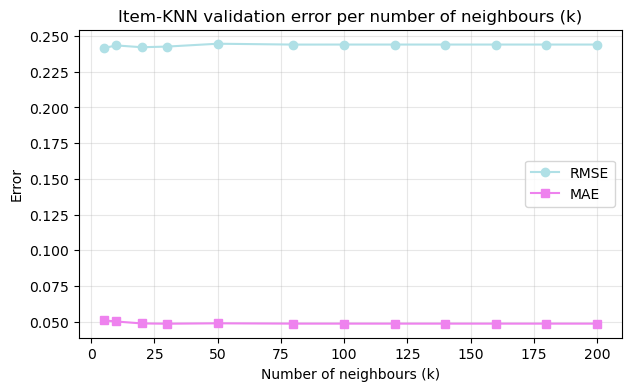

In [57]:
# Plot validation RMSE and MAE against the number of neighbours (k).
plt.figure(figsize=(7, 4))
plt.plot(knn_df['k'], knn_df['val_rmse'], marker='o', color='powderblue', label='RMSE')
plt.plot(knn_df['k'], knn_df['val_mae'], marker='s', color='violet', label='MAE')
plt.xlabel('Number of neighbours (k)')
plt.ylabel('Error')
plt.title('Item-KNN validation error per number of neighbours (k)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Interpretation

The validation RMSE is lowest at k=5 (0.2416) and is slightly higher for larger numbers of neighbours, settling at 0.2440 from about k=80 onwards. The differences are small, but the pattern is consistent: adding more neighbours does not improve the rating prediction and even makes it slightly worse. This matches the point from the lecture that a small number of high-confidence neighbours is preferable to many neighbours whose similarity weights are less trustworthy (Bhaumik, 2024b). On this sparse, view-dominated data, the few most similar items already carry the useful signal, and the extra neighbours mainly add noise.

The flattening of the RMSE for large k (a constant 0.2440 from k=80) is also informative. Beyond a certain point, increasing k no longer changes the prediction, because most items simply do not have many strongly similar neighbours: once all the genuinely similar items are included, the remaining neighbours have near-zero similarity and contribute almost nothing to the weighted average.

The MAE shows a slightly different pattern, reaching its lowest values (around 0.0487) at larger k. This small disagreement between RMSE and MAE is explained by how the two metrics treat errors: RMSE penalizes large errors more heavily, so it favours the smaller, more cautious neighbourhood of k=5, while MAE is less sensitive to the occasional large error. Because RMSE is the main metric used for tuning here, and the difference in MAE is tiny, k=5 is selected as the number of neighbours for the final model.

### 4.6 Final model and evaluation on the test set

With the best number of neighbours selected (k=5), the final model is trained on the combined training and validation data and then evaluated on the test set, which was not used during tuning. Combining training and validation gives the final model slightly more data to compute the item similarities from. The same predictive accuracy metrics as before (RMSE and MAE) are reported, so the result can be compared directly with the SVD model.

In [59]:
# Combine training and validation data for the final model.
train_val_df = pd.concat([train_df, val_df], ignore_index=True)

# Rebuild the item-session matrix on the combined data.
final_matrix = build_item_session_matrix(train_val_df, n_items, n_sessions)

# Recompute the item means on the combined data.
final_item_means = np.zeros(n_items, dtype=np.float32)
fmeans = train_val_df.groupby('item_idx')['rating'].mean()
final_item_means[fmeans.index.to_numpy()] = fmeans.to_numpy(dtype=np.float32)

# Mean-center the combined matrix (same vectorized approach as before).
final_centered = final_matrix.copy()
row_index = np.repeat(np.arange(n_items), np.diff(final_centered.indptr))
final_centered.data -= final_item_means[row_index]

# Normalize and fit the final neighbour model with the best k.
final_vectors = normalize(final_centered, norm='l2', axis=1)
final_neighbor_idx, final_neighbor_sim = fit_item_knn(final_vectors, k=best_k_item)

# Session-wise view of the combined matrix, for fast lookup during prediction.
final_by_session = final_matrix.T.tocsr()

print("Final Item-KNN model fitted with k =", best_k_item)

Final Item-KNN model fitted with k = 5


In [60]:
# Prediction function for the final model, using the combined-data objects.
def predict_final(session, item, min_neighbors=1):
    neighbors = final_neighbor_idx[item]
    sims = final_neighbor_sim[item]
    session_row = final_by_session[session]
    rated_items = session_row.indices
    rated_values = session_row.data

    num, den, used = 0.0, 0.0, 0
    for nb, sim in zip(neighbors, sims):
        if sim <= 0:
            continue
        pos = np.where(rated_items == nb)[0]
        if len(pos) == 0:
            continue
        rating = rated_values[pos[0]]
        num += sim * (rating - final_item_means[nb])
        den += sim
        used += 1

    if used < min_neighbors or den == 0:
        return float(np.clip(final_item_means[item], 1.0, 3.0))
    return float(np.clip(final_item_means[item] + num / den, 1.0, 3.0))

# Evaluate on the full test set (RMSE and MAE).
test_preds, test_actuals = [], []
for row in test_df.itertuples(index=False):
    test_preds.append(predict_final(int(row.session_idx), int(row.item_idx)))
    test_actuals.append(float(row.rating))

itemknn_rmse = sqrt(mean_squared_error(test_actuals, test_preds))
itemknn_mae = mean_absolute_error(test_actuals, test_preds)

print("Item-KNN test RMSE:", round(itemknn_rmse, 4))
print("Item-KNN test MAE:", round(itemknn_mae, 4))
print("(SVD test RMSE was:", round(svd_rmse, 4), "| MAE:", round(svd_mae, 4), ")")

Item-KNN test RMSE: 0.2769
Item-KNN test MAE: 0.0602
(SVD test RMSE was: 0.246 | MAE: 0.0641 )


### Interpretation

On the test set, Item-KNN reaches an RMSE of 0.2769 and an MAE of 0.0602. Compared with SVD (RMSE 0.246, MAE 0.0641), the two models trade places depending on the metric: SVD has the lower RMSE, while Item-KNN has the lower MAE. This split is informative, because RMSE and MAE respond differently to the kind of errors each model makes.

Item-KNN has a lower MAE, which means its predictions are on average slightly closer to the true rating. This fits the earlier observation that Item-KNN can predict values well above 1 when an item's neighbours were purchased, so it captures the rare purchases a little better than SVD, which predicted values close to 1 almost everywhere. However, Item-KNN has a higher RMSE. RMSE penalizes large errors more heavily, so the occasional confident-but-wrong prediction (for example predicting a value near 3 for an interaction that was actually a view) is punished more. SVD, by predicting cautiously close to 1 for nearly everything, avoids these large individual errors and therefore achieves a lower RMSE, even though its average error is slightly larger.

In short, Item-KNN is a little more willing to predict high ratings and is rewarded for it in MAE, but punished for its occasional large mistakes in RMSE. This is a meaningful difference in behaviour between a neighbourhood method and a matrix factorization method on this view-dominated data, rather than one model being simply better than the other.

### 4.7 Classification: predicting purchases

The second required evaluation treats Item-KNN as a classification task: instead of predicting the exact rating, the goal is to predict whether an interaction is a purchase. The ground truth is the `purchased` flag created in the EDA notebook (1 for a purchase, 0 for a view), which is a more direct target than thresholding a rating.

The predicted rating from Item-KNN is used as a score: a higher predicted rating means the model considers a purchase more likely. This score is evaluated in two ways. First, with AUC-ROC, which measures how well the scores separate purchases from views across all possible thresholds, without committing to one threshold. Second, by turning the score into a binary prediction with a threshold and computing precision, recall and F1.

This is important because the data is highly imbalanced: only about 1.5% of interactions are purchases. With such imbalance, accuracy is misleading, because always predicting "no purchase" would already be about 98.5% accurate. Precision, recall, F1 and AUC-ROC are therefore the appropriate metrics, as they focus on how well the rare purchase class is identified (Bhaumik, 2024a).

To make the errors easy to read, a confusion matrix is also reported. It shows how often each true class (view or purchase) is predicted correctly or confused with the other class: correct predictions lie on the diagonal, while the off-diagonal cells show the two types of mistake (views wrongly flagged as purchases, and purchases that were missed). The precision and recall above are computed directly from these four counts.

In [61]:
from sklearn.metrics import (roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix)

# Predict a rating (score) for every interaction in the test set.
# This reuses the final model; the higher the score, the more likely a purchase.
test_scores = np.array([predict_final(int(r.session_idx), int(r.item_idx))
                        for r in test_df.itertuples(index=False)])

# The true labels are the purchase flags from the EDA notebook.
test_labels = test_df['purchased'].to_numpy()

print("Test interactions:", len(test_labels))
print("Purchases in test set:", int(test_labels.sum()),
      f"({test_labels.mean():.2%})")

Test interactions: 130643
Purchases in test set: 2143 (1.64%)


In [62]:
# AUC-ROC uses the continuous score directly (no threshold needed).
auc = roc_auc_score(test_labels, test_scores)

# For precision/recall/F1 the score is turned into a 0/1 prediction with a threshold.
# A purchase has rating 3 and a view rating 1, so a threshold of 2 sits in between: predicted rating above 2 is classified as a purchase.
threshold = 2.0
test_pred_class = (test_scores > threshold).astype(int)

precision = precision_score(test_labels, test_pred_class, zero_division=0)
recall = recall_score(test_labels, test_pred_class, zero_division=0)
f1 = f1_score(test_labels, test_pred_class, zero_division=0)

print("AUC-ROC:  ", round(auc, 4))
print("Precision:", round(precision, 4))
print("Recall:   ", round(recall, 4))
print("F1-score: ", round(f1, 4))
print("\nConfusion matrix (rows = true, cols = predicted):")
print(confusion_matrix(test_labels, test_pred_class))

AUC-ROC:   0.5461
Precision: 0.1124
Recall:    0.0182
F1-score:  0.0313

Confusion matrix (rows = true, cols = predicted):
[[128192    308]
 [  2104     39]]


### Interpretation

The classification results show that Item-KNN struggles to identify purchases on this data. The AUC-ROC is 0.5461, only slightly above 0.5, which is the score of random guessing. This means the predicted ratings carry a small but real signal for separating purchases from views, but the separation is weak.

The precision, recall and F1 are all low. With a threshold of 2, the model predicts a purchase for only 347 of the 130,643 test interactions (308 + 39 from the confusion matrix), and of those only 39 are actual purchases, giving a precision of 0.11. Out of the 2,143 real purchases, it correctly flags just 39, giving a recall of 0.018. In other words, the model almost always predicts "no purchase", and when it does predict a purchase it is usually wrong.

This behaviour is a direct consequence of the data. Because purchases make up only 1.64% of interactions, and the predicted ratings sit close to 1 for almost all interactions, very few predictions cross the threshold of 2. The

### 4.8 Top-N ranking evaluation

As with SVD, Item-KNN is also evaluated on ranking quality, so the two techniques can be compared on the same basis. The same evaluation function and the same values of K are used: for each sampled test session, every item is scored, the held-out test items are treated as relevant, and Precision@K, Recall@K and HitRate@K are computed. Items the session already interacted with in training are excluded. This measures whether Item-KNN puts the relevant items near the top of its recommendation list, which is the part of the task that SVD struggled with.

In [63]:
# Build a session x item view of the final training matrix for fast lookup.
# For scoring, the predicted rating of an item for a session is the similarity-weighted average of the session's ratings on that item's neighbours (relative to item means).
# This is computed for all items at once, so evaluate_topn stays fast.

# Pre-extract neighbour indices/similarities and item means as arrays.
final_means = final_item_means

def itemknn_scores(session, items):
    # Ratings this session gave, as a dense vector over all items (mostly zero).
    session_row = final_by_session[session]
    rated = np.zeros(n_items, dtype=np.float32)
    rated[session_row.indices] = session_row.data
    # Mask of which items the session actually interacted with.
    seen_mask = np.zeros(n_items, dtype=bool)
    seen_mask[session_row.indices] = True

    # For every queried item, gather its k neighbours and their similarities.
    nb = final_neighbor_idx[items]          # shape (len(items), k)
    sim = final_neighbor_sim[items]         # shape (len(items), k)

    # Rating the session gave to each neighbour, and whether it interacted with it.
    nb_rating = rated[nb]                   # 0 where not interacted with
    nb_seen = seen_mask[nb]                 # True where the session rated the neighbour
    nb_mean = final_means[nb]

    # Only neighbours with positive similarity and interacted with count.
    valid = (sim > 0) & nb_seen
    weighted = np.where(valid, sim * (nb_rating - nb_mean), 0.0).sum(axis=1)
    denom = np.where(valid, sim, 0.0).sum(axis=1)

    # Prediction = item mean + weighted deviation, fall back to item mean if no neighbours.
    out = final_means[items].astype(np.float32).copy()
    nonzero = denom > 0
    out[nonzero] = final_means[items][nonzero] + weighted[nonzero] / denom[nonzero]
    return out

# Run the ranking evaluation at the same K values used for SVD.
print("Item-KNN ranking:")
for K in [10, 20, 50, 100]:
    res = evaluate_topn(itemknn_scores, K=K)
    print(f"K={K:3d} | Precision: {res['precision']:.4f} | "
          f"Recall: {res['recall']:.4f} | HitRate: {res['hitrate']:.4f}")

Item-KNN ranking:
K= 10 | Precision: 0.0001 | Recall: 0.0005 | HitRate: 0.0005
K= 20 | Precision: 0.0001 | Recall: 0.0010 | HitRate: 0.0010
K= 50 | Precision: 0.0001 | Recall: 0.0025 | HitRate: 0.0025
K=100 | Precision: 0.0000 | Recall: 0.0040 | HitRate: 0.0040


### Interpretation

On ranking, Item-KNN performs better than SVD but still well below the popularity baseline. Its HitRate rises from 0.0005 at K=10 to 0.0040 at K=100, which is consistently higher than SVD (0.0 at K=10, 0.0015 at K=100) but clearly lower than the popularity baseline (0.0305 at K=100). The precision stays near zero at all K, because with a single held-out item per session and about 41,000 items, almost none of the top-K slots can be correct; recall and HitRate are more meaningful here, since they measure whether the one relevant item is found at all.

That Item-KNN ranks better than SVD is consistent with the earlier observations. Item-KNN bases its recommendations on the specific items a session interacted with, so its scores vary more between sessions and carry a little more session-specific signal. SVD, in contrast, predicted values close to 1 for almost every item, leaving its ranking close to random. Item-KNN therefore makes more use of the session history, which gives it a small but real ranking advantage.

At the same time, neither model beats the simple popularity baseline, which remains the strongest of the three for ranking. This reinforces the main finding of the project: on sparse, view-dominated e-commerce data, ranking the exact held-out item highly is very hard for both collaborative filtering techniques, and a non-personalized popularity rule is a strong reference that is difficult to beat.

### 4.9 Example top-N recommendations

To make the Item-KNN output concrete, the top-10 recommendations are generated for the same two example sessions used for SVD: a randomly chosen session and the most active session. For each session, the items it interacted with in training are shown next to the items Item-KNN recommends, so the two can be compared. As with SVD, the items are anonymized, so each recommendation is shown with its category and log2 price for context rather than a product name.

In [64]:
# Recommend the top-K items for a session using the Item-KNN scores, excluding items the session already interacted with in training.
def recommend_itemknn(session, K=10):
    all_items = np.arange(n_items)
    scores = itemknn_scores(session, all_items)        # score every item

    # Exclude items already seen by this session in the combined training data.
    seen = final_by_session[session].indices
    scores[seen] = -np.inf

    # Take the top-K items, highest score first.
    top_k = np.argpartition(-scores, K)[:K]
    return top_k[np.argsort(-scores[top_k])]

def show_session_itemknn(session, K=10):
    # Items the session interacted with in the combined training data.
    seen = sorted(final_by_session[session].indices)
    print(f"Session {session} interacted with {len(seen)} items in training.")
    print("\nItems this session interacted with (first 10):")
    print(describe_items(seen[:10]).to_string(index=False))
    print("\nTop-10 recommendations from Item-KNN:")
    print(describe_items(recommend_itemknn(session, K)).to_string(index=False))

In [65]:
# Example 1: the same random session approach as used for SVD.
example_rng = np.random.default_rng(7)
random_session = int(example_rng.choice(test_items_per_session.index.to_numpy()))

print("=== Example 1: random session ===")
show_session_itemknn(random_session)

=== Example 1: random session ===
Session 122814 interacted with 3 items in training.

Items this session interacted with (first 10):
 item_idx  item_id  category_id  log2price
     4017    12862           47          8
     4489   379027          952          8
    17602   161061           47          9

Top-10 recommendations from Item-KNN:
 item_idx  item_id  category_id  log2price
    39828   380140          380          0
    40773    15270          412          9
    41188     3141          788          8
    21885   253898          895          4
     2012   108240         1080          5
    24221    92426         1063          8
    20761     9381         1269          0
    15170   160639          479          7
    25108   148830           74          7
    26578   135744          109          8


### Interpretation

This randomly chosen session interacted with three items from categories 47 and 952. The ten items recommended by Item-KNN come from a wide range of other categories (380, 412, 788, and so on) and none of them are from categories 47 or 952. So even though Item-KNN uses item similarity, the recommendations for this short session are not clearly related to the categories it viewed. This is understandable: with only three interactions, the session provides very little history for the model to base similar-item recommendations on.

In [66]:
# Example 2: the most active session (most interactions in training).
most_active_session = int(train_df['session_idx'].value_counts().idxmax())

print("=== Example 2: most active session ===")
show_session_itemknn(most_active_session)

=== Example 2: most active session ===
Session 39282 interacted with 63 items in training.

Items this session interacted with (first 10):
 item_idx  item_id  category_id  log2price
      990    83866          634          0
     1692    41310          634         10
     2249    73734          634          9
     2816     6909          634          9
     2834    34113          634          9
     2836    71995          634          0
     3108    36780          634          9
     3978    33861          634          9
     4031    12220          634          0
     4251    13069          634          9

Top-10 recommendations from Item-KNN:
 item_idx  item_id  category_id  log2price
    39828   380140          380          0
    39998   168498         1111          6
    25225    76601          730          6
    34918   251327          277          7
    15170   160639          479          7
    35905    32808         1265          5
    26578   135744          109          8
    2

### Interpretation

The most active session is far more informative: it interacted with 63 items, all from category 634. A model that uses item similarity well would be expected to recommend more items from category 634, or from closely related categories. However, the top-10 recommendations from Item-KNN contain no items from category 634; they come from many unrelated categories (380, 1111, 730, and others). The recommendations are also very similar to those given to the random session, with several identical items appearing in both lists.

This is a revealing result. Despite Item-KNN ranking slightly better than SVD in the earlier evaluation, its concrete recommendations are still not strongly session-specific, and it does not pick up the clear category-634 preference of this session. The likely reason lies in the data and the method combined: the recommendation step scores every item, and items that have many neighbours with non-zero similarity and slightly higher means tend to receive similar scores across sessions, which produces a recommendation list dominated by a few generally well-connected items rather than items tailored to the session. In other words, even a method based on item similarity is pulled towards a small set of broadly similar items on this sparse, view-dominated data, echoing the behaviour seen with SVD.

### 4.10 Comparison of the techniques

This section brings together the results of all models on the test set, so the two techniques (and the SVD++ extension and the popularity baseline) can be compared directly. The comparison covers the predictive accuracy (RMSE and MAE), the ranking quality (HitRate@100 as a representative ranking score), and, for Item-KNN, the classification of purchases.

In [68]:
# Collect the main test-set results of all models into one comparison table.
# Ranking is summarized by HitRate@100 (the least strict K used).
comparison = pd.DataFrame([
    {'Model': 'SVD',            'Test RMSE': round(svd_rmse, 4),   'Test MAE': round(svd_mae, 4),   'HitRate@100': 0.0015},
    {'Model': 'SVD++',          'Test RMSE': round(svdpp_rmse, 4), 'Test MAE': round(svdpp_mae, 4), 'HitRate@100': 0.0015},
    {'Model': 'Item-KNN',       'Test RMSE': round(itemknn_rmse, 4),'Test MAE': round(itemknn_mae, 4),'HitRate@100': 0.0040},
    {'Model': 'Popularity',     'Test RMSE': None,                 'Test MAE': None,                'HitRate@100': 0.0305},
])

print(comparison.to_string(index=False))

     Model  Test RMSE  Test MAE  HitRate@100
       SVD     0.2460    0.0641       0.0015
     SVD++     0.2463    0.0646       0.0015
  Item-KNN     0.2769    0.0602       0.0040
Popularity        NaN       NaN       0.0305


### Interpretation

The table shows that no single model is best on every metric. On rating prediction, SVD and SVD++ have the lowest RMSE (around 0.246), while Item-KNN has the lowest MAE (0.0602). On ranking, Item-KNN scores highest of the three collaborative filtering models (HitRate@100 of 0.0040 versus 0.0015 for SVD and SVD++), but all three are clearly beaten by the popularity baseline (0.0305). The popularity model has no RMSE or MAE because it only produces a ranking and does not predict ratings. The detailed reasons behind these differences were discussed in the sections above, and their wider implications are drawn together in the overall conclusion.

### 4.11 Conclusion: Item-KNN

Item-based collaborative filtering (Item-KNN) was built from scratch, using mean-centering, cosine similarity, and a similarity-weighted neighbourhood prediction, with the number of neighbours tuned on the validation set (k=5). It was tested both as a rating predictor and as a classifier, as required.

As a rating predictor it reached a test RMSE of 0.277 and MAE of 0.060, slightly worse than SVD on RMSE but a bit better on MAE. As a classifier of purchases it got an AUC-ROC of 0.546, only just above random, with a low recall. So, it caught very few of the rare purchases. On ranking it did better than SVD but still lost clearly to the popularity baseline, and the example recommendations were not strongly session-specific and missed the clear category preference of the most active session.

Overall, Item-KNN uses the session's history a little better than SVD, which gives it a small edge in ranking and in catching purchases. It is still held back by the data, though: with almost everything being views, there is little signal to learn strong item relationships or to spot purchases. So, its practical recommendations stay weak, as the examples showed.

## 5. Overall conclusion

This notebook applied two recommender techniques to the Diginetica data, both built from scratch: matrix factorization (SVD, with SVD++ as a bonus) and item-based collaborative filtering (Item-KNN). Each one was tested on rating prediction, ranking, and, where relevant, classification, so they could be compared on the same footing.

All the models predicted the proxy rating accurately, with a low RMSE (around 0.25) and MAE (around 0.06). On its own that looks good, but it is misleading: the data is almost all views (rating 1) with only about 1.6% purchases, so predicting something close to 1 for everything is already correct most of the time. The harder tasks showed where the models actually struggle. On ranking, all of the personalized models scored close to random and lost to a simple popularity baseline, and on classification Item-KNN caught only a small share of the rare purchases.

The differences between the techniques were small but consistent. SVD got the lowest RMSE by predicting cautiously, Item-KNN got the lowest MAE and ranked a bit better by leaning on the session's own history, and SVD++ ended up almost identical to plain SVD, so the extra implicit-feedback term did not really pay off here. None of them produced strongly session-specific recommendations in the worked examples.

What I take from this is that the main challenge is the data, not the choice of technique. On sparse, view-dominated e-commerce interactions, a low rating error does not mean good recommendations, a more complex model is not automatically better, and the metric you pick matters as much as the model. The most promising next step would be to treat the problem as implicit-feedback ranking from the start, for example as a session-based next-item task, instead of predicting a proxy rating, so the training objective lines up with the actual goal of recommending relevant items.

## References

Bhaumik, D. (2024a). RecSys – Basic Techniques [Lecture slides]. Amsterdam University of Applied Sciences.

Bhaumik, D. (2024b). RecSys – Techniques 2 [Lecture slides]. Amsterdam University of Applied Sciences.

Ji, Y., Sun, A., Zhang, J., & Li, C. (2020). A re-visit of the popularity baseline in recommender systems. In *Proceedings of the 43rd International ACM SIGIR Conference on Research and Development in Information Retrieval* (pp. 1749–1752). https://doi.org/10.1145/3397271.3401233

Koren, Y., Bell, R., & Volinsky, C. (2009). Matrix factorization techniques for recommender systems. *Computer, 42*(8), 30–37. https://doi.org/10.1109/MC.2009.263

## Use of AI Tools

AI tools were used in a supporting role only, not to generate the solution. They were consulted to clarify recommender system concepts, to help with debugging, to explain how certain methods or libraries work when needed, and to help make sure that the interpretations and the steps taken were worded clearly and correctly. 